In [49]:
import os, sys
sys.path.append('../')

import pandas as pd
import numpy as np

import importlib
importlib.reload(FOM)
importlib.reload(fitf)


import FOM_functions      as FOM
import cutting_functions  as cutf
import fitting_functions  as fitf
import plotting_functions as plotf

In [5]:
# load in data
data = pd.read_hdf('../data/th_port1a_dep_202602_subsample_250326_9.h5', 'Tracking/Tracks') 
display(data)

,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
5,150400003,0,1.596928,221.603988,522,51923,1,-89.125,-203.425,543.194016,...,651.077410,1.958085,-101.735779,556.192276,0.848508,0.378778,0.0,8.642857,8.812500,8.647897
6,150400004,0,1.593875,328.414450,494,38604,1,27.875,-146.425,163.199113,...,185.068755,135.875000,-43.425000,315.864756,0.711392,0.529600,0.0,9.000000,8.500000,8.745341
59,150400031,0,1.589366,188.781678,612,55486,1,-51.125,-57.425,1057.258039,...,1079.270027,49.832282,9.669873,1150.678820,0.782653,0.450609,0.0,8.705882,8.769231,8.794019
78,150400038,0,1.597833,274.216092,632,54323,1,-146.125,6.575,583.210427,...,623.394301,-54.914349,43.295842,678.374580,0.591015,0.344177,0.0,8.529412,8.714286,8.901459
124,150400060,0,1.612251,526.637424,724,50774,1,-226.125,-212.425,58.671658,...,315.143577,-141.379452,-97.106394,79.286219,0.606620,0.143228,0.0,9.000000,8.750000,8.889346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,621300075,0,1.588095,365.643224,534,49150,1,25.875,-116.425,103.092302,...,234.052080,62.926716,-7.094240,113.401170,0.521280,0.485874,0.0,8.857143,8.944444,8.861059
179,621300088,0,1.580836,343.539269,544,46380,1,7.875,40.575,167.744646,...,368.295207,121.959778,102.159124,177.365649,1.133705,0.066183,0.0,9.000000,9.000000,8.949392
203,621300102,0,1.587656,350.069478,604,55949,1,-159.125,-33.425,484.907496,...,599.359285,41.579770,119.430657,497.434584,0.786967,0.210422,0.0,8.923077,8.714286,8.453185
251,621300126,0,1.601880,274.743982,656,56851,1,17.875,-198.425,800.691015,...,954.020726,171.015130,-137.499706,821.364008,0.643020,0.416157,0.0,8.900000,8.545455,8.847449


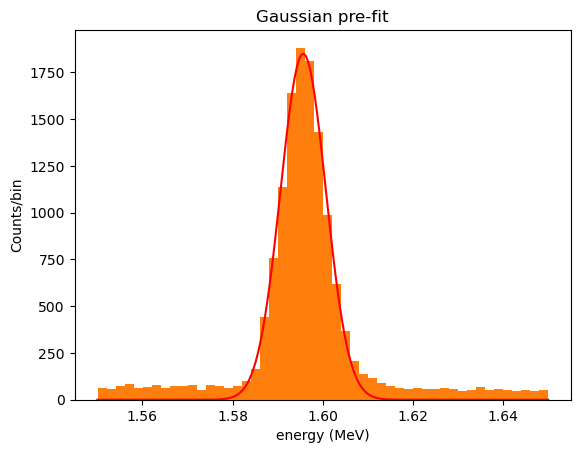

Blob cut: 0.0 MeV
Signal events: 11340.936778704381
Background events: 6433.592868719353
Total events by addition: 17774.529647423733
Total events by row counting: 17775
FOM: 1.0 +/- 0.01593955290565619
Blob cut: 0.016666666666666666 MeV
Signal events: 11313.547266989572
Background events: 6407.031243245409
Total events by addition: 17720.57851023498
Total events by row counting: 17721
FOM: 0.99965060346697 +/- 0.01594572481641808
Blob cut: 0.03333333333333333 MeV
Signal events: 11275.369953825393
Background events: 6340.2992297281535
Total events by addition: 17615.669183553546
Total events by row counting: 17616
FOM: 1.0015065192740908 +/- 0.015997601151243167
Blob cut: 0.05 MeV
Signal events: 11237.468895160036
Background events: 6208.330666023041
Total events by addition: 17445.799561183077
Total events by row counting: 17446
FOM: 1.0086928452181576 +/- 0.016148260683466628
Blob cut: 0.06666666666666667 MeV
Signal events: 11184.427791314574
Background events: 5917.47428594858
Total

/home/e78368jw/Documents/NEXT_CODE/next_misc/new_FOM_method/testing/../FOM_functions.py:199: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [50]:
cut_list = np.linspace(0, 0.6, 31)
fit_info = dict(bins = 80, fit_range = (1.4, 1.8))

mu_config    = dict(
                value    = 1.59,
                floating = False,
                lower    = 1.4,
                upper    = 1.8)

sigma_config = dict(
                value    = 0.1,
                floating = False,
                lower    = 0)

tau_config   = dict(
                value    = 0.03,
                floating = False,
                lower    = 0,
                upper    = 1)


seeds = dict(
            ns = data.event.nunique()/2,
            nb = data.event.nunique()/2,
            signal = {'mu_config': mu_config,
                      'sigma_config': sigma_config},
            background = {'lambda_config': tau_config})

x = FOM.FOM(data, fitf.gaussian_no_N, fitf.exp_no_N, seeds = seeds, fitting_info = fit_info, plot = True, output_path = './output/')



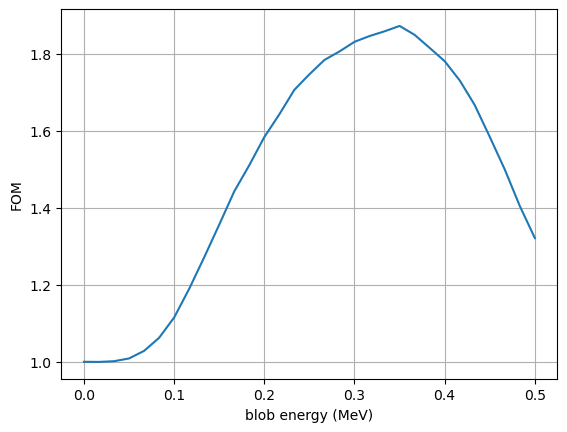

In [56]:
# load in the csv and visualise
import csv
import matplotlib.pyplot as plt

def read_FOM_csv(path):
    data = np.genfromtxt(path, delimiter=',')
    n    = len(data) // 5

    return dict(
        cut_list = data[0*n : 1*n, 0],
        fom      = data[0*n : 1*n, 1],
        fom_err  = data[1*n : 2*n, 1],
        ns_l     = data[2*n : 3*n, 0],
        nb_l     = data[2*n : 3*n, 1],
        e        = data[3*n : 4*n, 0],
        e_err    = data[3*n : 4*n, 1],
        b        = data[4*n : 5*n, 0],
        b_err    = data[4*n : 5*n, 1],
    )

FOM_info = read_FOM_csv('output/FOM.csv')

plt.plot(FOM_info['cut_list'], FOM_info['fom'])
plt.xlabel('blob energy (MeV)')
plt.ylabel('FOM')
plt.grid()
plt.show()